In [1]:
import ast
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ------------------ Style (match yours) ------------------
rcParams["font.family"] = "Lato"
rcParams["font.size"] = 16
rcParams["text.color"] = "#3F3F3F"
rcParams["axes.labelcolor"] = "#3F3F3F"
rcParams["xtick.color"] = "#3F3F3F"
rcParams["ytick.color"] = "#3F3F3F"

TEAL = ["#b5d1ae", "#80ae9a", "#568b87", "#326b77", "#1b485e", "#122740"]

FEATURES = ["length","is_assembled","ap","has_beta_sheet_content","hydrophobic_moment","net_charge"]

def _as_list(x):
    """Robust parse for used_features stored as list or string repr."""
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            if isinstance(v, (list, tuple)):
                return list(v)
        except Exception:
            return [t.strip() for t in x.split(",") if t.strip()]
    return []

def count_k_used(used_features, include_length=True):
    used = set(_as_list(used_features))
    feats = FEATURES if include_length else [f for f in FEATURES if f != "length"]
    return sum(f in used for f in feats)

def row_success_all_targeted(row, include_length=True):
    """
    "All-constraints" success for THIS row: all targeted descriptors satisfied.
    Uses match_* booleans already in your samples_df.
    """
    used = set(_as_list(row.get("used_features", [])))
    feats = FEATURES if include_length else [f for f in FEATURES if f != "length"]
    targeted = [f for f in feats if f in used]
    if not targeted:
        return False
    for f in targeted:
        v = row.get(f"match_{f}", pd.NA)
        if pd.isna(v) or (bool(v) is False):
            return False
    return True

def bootstrap_ci_mean(values, n_boot=5000, alpha=0.05, rng=None):
    """
    Nonparametric bootstrap CI for mean of 1D array-like values.
    """
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(0) if rng is None else rng
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1 - alpha/2)
    return float(x.mean()), float(lo), float(hi)

def bootstrap_ci_over_conditions(cond_values_df, value_col, n_boot=5000, alpha=0.05):
    """
    Bootstrap over conditions: resample cond_idx rows with replacement.
    Assumes one row per condition.
    """
    x = cond_values_df[value_col].to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(0)
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1 - alpha/2)
    return float(x.mean()), float(lo), float(hi)


In [2]:
def load_results_pickle(pkl_path: str):
    with open(pkl_path, "rb") as f:
        results = pickle.load(f)
    if "samples_df" not in results:
        raise KeyError("results.pkl must contain 'samples_df'")
    samples_df = results["samples_df"].copy()
    within_df = results.get("within_df", None)
    cond_meta_df = results.get("cond_meta_df", None)  # optional
    return samples_df, within_df, cond_meta_df

def build_condition_summary(samples_df: pd.DataFrame, include_length_in_k=True) -> pd.DataFrame:
    """
    Returns ONE ROW per cond_idx with:
      - k (# targeted descriptors)
      - all_target_success_rate (mean over the 100 samples)
      - per-feature match rates (conditional on feature being targeted)
      - within-condition similarity mean (from sim_gen_within) and train similarity (sim_train)
      - uniqueness within condition (% unique)
    """
    df = samples_df.copy()
    df["k"] = df["used_features"].apply(lambda u: count_k_used(u, include_length=include_length_in_k))
    df["success_all"] = df.apply(lambda r: row_success_all_targeted(r, include_length=include_length_in_k), axis=1)

    # per-feature match booleans are already columns match_*
    # We'll compute, per condition, the mean match for each feature over rows where that feature is targeted.
    rows = []
    for cid, g in df.groupby("cond_idx", sort=True):
        used0 = g["used_features"].iloc[0]
        used = set(_as_list(used0))
        k = int(count_k_used(used0, include_length=include_length_in_k))

        out = {
            "cond_idx": int(cid),
            "k": k,
            "ood_type": g["ood_type"].iloc[0] if "ood_type" in g.columns else "unknown",
            "all_target_success_rate": float(g["success_all"].mean()),
            "uniq_pct": 100.0 * (g["sequence"].nunique() / len(g)),
        }

        # similarity columns (these are per-peptide averages)
        for col in ["sim_gen_within", "sim_gen_all", "sim_train"]:
            if col in g.columns:
                out[col + "_mean"] = float(np.nanmean(g[col].to_numpy(dtype=float)))
            else:
                out[col + "_mean"] = np.nan

        # per-feature match rates (only if targeted)
        for f in FEATURES:
            match_col = f"match_{f}"
            if match_col not in g.columns:
                out[f"match_rate_{f}"] = np.nan
                out[f"n_targeted_{f}"] = 0
                continue
            mask_targeted = g["used_features"].apply(lambda u: f in set(_as_list(u))).to_numpy(dtype=bool)
            vals = g.loc[mask_targeted, match_col].dropna()
            out[f"n_targeted_{f}"] = int(vals.shape[0])
            out[f"match_rate_{f}"] = float(vals.astype(bool).mean()) if len(vals) else np.nan

        rows.append(out)

    return pd.DataFrame(rows).sort_values("cond_idx").reset_index(drop=True)

In [3]:
samples_df, within_df, cond_meta_df = load_results_pickle("./results/cvae_evaluation_results.pkl")
cond_summary = build_condition_summary(samples_df, include_length_in_k=True)

if within_df is not None:
    cond_summary = cond_summary.merge(within_df[["cond_idx","mean","uniq_pct"]].rename(columns={"mean":"ned_within_mean_from_within_df",
                                                                                               "uniq_pct":"uniq_pct_from_within_df"}),
                                      on="cond_idx", how="left")


In [4]:
def make_ci_table(cond_summary: pd.DataFrame, use_only_in_dist=True) -> pd.DataFrame:
    """
    Returns a tidy table with mean and 95% CI over conditions.
    """
    df = cond_summary.copy()
    if use_only_in_dist and "ood_type" in df.columns:
        df = df[df["ood_type"] == "in_dist"].copy()

    metrics = [
        ("All-target success rate", "all_target_success_rate"),
        ("Within-cond uniqueness (%)", "uniq_pct"),
        ("Within-cond mean NED", "ned_within_mean_from_within_df" if "ned_within_mean_from_within_df" in df.columns else None),
        ("Within-cond mean NW %id", "sim_gen_within_mean"),
        ("Gen-vs-train mean NW %id", "sim_train_mean"),
    ]

    # Add per-descriptor match rates
    for f in FEATURES:
        metrics.append((f"Match rate: {f}", f"match_rate_{f}"))

    rows = []
    for name, col in metrics:
        if col is None or col not in df.columns:
            continue
        mean, lo, hi = bootstrap_ci_over_conditions(df, col)
        rows.append({
            "metric": name,
            "mean": mean,
            "ci_low": lo,
            "ci_high": hi
        })

    out = pd.DataFrame(rows)

    # Prettify (rates as % where appropriate)
    def _fmt(row):
        m = row["mean"]
        lo = row["ci_low"]
        hi = row["ci_high"]
        if "rate" in row["metric"].lower() or "%id" in row["metric"].lower():
            return f"{100*m:.1f} [{100*lo:.1f}, {100*hi:.1f}]"
        if "(%)" in row["metric"]:
            return f"{m:.1f} [{lo:.1f}, {hi:.1f}]"
        return f"{m:.3f} [{lo:.3f}, {hi:.3f}]"

    out["mean [95% CI]"] = out.apply(_fmt, axis=1)
    return out[["metric", "mean [95% CI]"]]

ci_table = make_ci_table(cond_summary, use_only_in_dist=True)
ci_table


,metric,mean [95% CI]
0,All-target success rate,"51.1 [45.0, 57.1]"
1,Within-cond uniqueness (%),"100.0 [100.0, 100.0]"
2,Within-cond mean NED,"0.912 [0.908, 0.917]"
3,Within-cond mean NW %id,"9.3 [8.9, 9.7]"
4,Gen-vs-train mean NW %id,"9.6 [9.5, 9.7]"
5,Match rate: length,"99.8 [99.5, 100.0]"
6,Match rate: is_assembled,"80.9 [77.4, 84.2]"
7,Match rate: ap,"79.7 [76.0, 83.4]"
8,Match rate: has_beta_sheet_content,"97.7 [94.3, 99.8]"
9,Match rate: hydrophobic_moment,"62.6 [58.0, 67.0]"


In [5]:
# LaTeX export (booktabs friendly)
print(ci_table.to_latex(index=False, escape=False))

\begin{tabular}{ll}
\toprule
metric & mean [95% CI] \\
\midrule
All-target success rate & 51.1 [45.0, 57.1] \\
Within-cond uniqueness (%) & 100.0 [100.0, 100.0] \\
Within-cond mean NED & 0.912 [0.908, 0.917] \\
Within-cond mean NW %id & 9.3 [8.9, 9.7] \\
Gen-vs-train mean NW %id & 9.6 [9.5, 9.7] \\
Match rate: length & 99.8 [99.5, 100.0] \\
Match rate: is_assembled & 80.9 [77.4, 84.2] \\
Match rate: ap & 79.7 [76.0, 83.4] \\
Match rate: has_beta_sheet_content & 97.7 [94.3, 99.8] \\
Match rate: hydrophobic_moment & 62.6 [58.0, 67.0] \\
Match rate: net_charge & 70.1 [60.5, 79.4] \\
\bottomrule
\end{tabular}



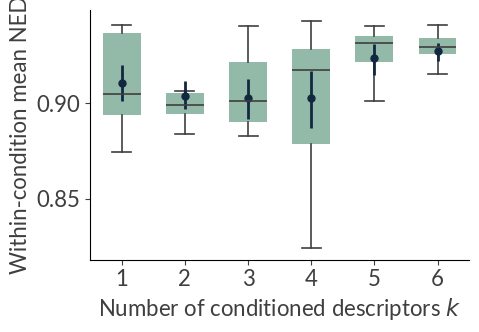

In [6]:
def plot_within_condition_ned_by_k(cond_summary: pd.DataFrame,
                                  outpath="fig_within_condition_ned_by_k.svg"):
    df = cond_summary.copy()
    df = df[df["ood_type"] == "in_dist"].copy() if "ood_type" in df.columns else df
    if "ned_within_mean_from_within_df" not in df.columns:
        raise ValueError("Need within-condition NED per condition. Merge within_df first.")
    df = df[np.isfinite(df["ned_within_mean_from_within_df"].to_numpy(dtype=float))]

    # collect data per k
    ks = sorted(df["k"].unique().tolist())
    data = [df.loc[df["k"] == k, "ned_within_mean_from_within_df"].to_numpy(dtype=float) for k in ks]

    fig, ax = plt.subplots(figsize=(5.2, 3.6))

    bp = ax.boxplot(
        data,
        positions=np.arange(1, len(ks)+1),
        widths=0.6,
        patch_artist=True,
        showfliers=False
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(TEAL[1])
        patch.set_alpha(0.85)
        patch.set_linewidth(0)

    for elem in ["whiskers", "caps", "medians"]:
        for line in bp[elem]:
            line.set_color("#3F3F3F")
            line.set_linewidth(1.2)

    # overlay mean ± bootstrap CI per k
    for i, k in enumerate(ks, start=1):
        vals = df.loc[df["k"] == k, "ned_within_mean_from_within_df"].to_numpy(dtype=float)
        mean, lo, hi = bootstrap_ci_mean(vals, n_boot=4000)
        ax.plot([i], [mean], marker="o", markersize=5, color=TEAL[5])
        ax.vlines(i, lo, hi, color=TEAL[5], linewidth=2)

    ax.set_xticks(np.arange(1, len(ks)+1))
    ax.set_xticklabels([str(k) for k in ks])
    ax.set_xlabel("Number of conditioned descriptors $k$")
    ax.set_ylabel("Within-condition mean NED")

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    fig.savefig(outpath, format="svg", bbox_inches="tight", dpi=300)
    plt.show()

plot_within_condition_ned_by_k(cond_summary)


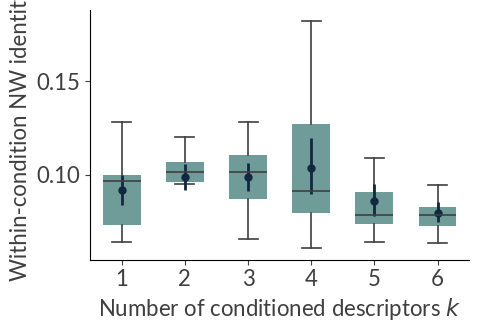

In [7]:
def plot_within_condition_nw_by_k(cond_summary: pd.DataFrame,
                                 outpath="fig_within_condition_nw_by_k.svg"):
    df = cond_summary.copy()
    df = df[df["ood_type"] == "in_dist"].copy() if "ood_type" in df.columns else df
    col = "sim_gen_within_mean"
    if col not in df.columns:
        raise ValueError("Need sim_gen_within_mean in cond_summary (computed from samples_df).")
    df = df[np.isfinite(df[col].to_numpy(dtype=float))]

    ks = sorted(df["k"].unique().tolist())
    data = [df.loc[df["k"] == k, col].to_numpy(dtype=float) for k in ks]

    fig, ax = plt.subplots(figsize=(5.2, 3.6))

    bp = ax.boxplot(
        data,
        positions=np.arange(1, len(ks)+1),
        widths=0.6,
        patch_artist=True,
        showfliers=False
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(TEAL[2])
        patch.set_alpha(0.85)
        patch.set_linewidth(0)

    for elem in ["whiskers", "caps", "medians"]:
        for line in bp[elem]:
            line.set_color("#3F3F3F")
            line.set_linewidth(1.2)

    # mean ± CI
    for i, k in enumerate(ks, start=1):
        vals = df.loc[df["k"] == k, col].to_numpy(dtype=float)
        mean, lo, hi = bootstrap_ci_mean(vals, n_boot=4000)
        ax.plot([i], [mean], marker="o", markersize=5, color=TEAL[5])
        ax.vlines(i, lo, hi, color=TEAL[5], linewidth=2)

    ax.set_xticks(np.arange(1, len(ks)+1))
    ax.set_xticklabels([str(k) for k in ks])
    ax.set_xlabel("Number of conditioned descriptors $k$")
    ax.set_ylabel("Within-condition NW identity")

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    fig.savefig(outpath, format="svg", bbox_inches="tight", dpi=300)
    plt.show()

plot_within_condition_nw_by_k(cond_summary)

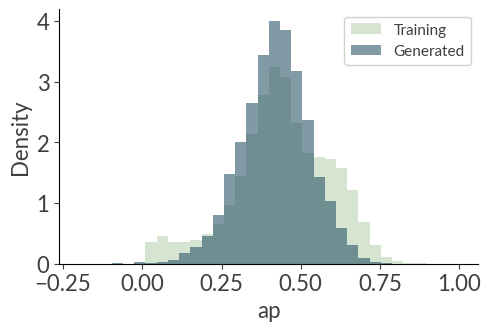

In [8]:
def plot_marginal_distribution_overlay(train_df: pd.DataFrame,
                                       samples_df: pd.DataFrame,
                                       feature: str,
                                       pred_col: str,
                                       outpath: str):
    """
    Overlay histograms: training feature distribution vs generated predicted feature distribution.
    pred_col should exist in samples_df (e.g., pred_ap, pred_hydrophobic_moment, pred_net_charge).
    """
    tr = train_df[feature].dropna().to_numpy(dtype=float)
    ge = samples_df[pred_col].dropna().to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(5.2, 3.6))

    # Use common bins from combined range
    lo = float(np.nanmin(np.concatenate([tr, ge])))
    hi = float(np.nanmax(np.concatenate([tr, ge])))
    bins = np.linspace(lo, hi, 35)

    ax.hist(tr, bins=bins, density=True, alpha=0.55, label="Training", color=TEAL[0])
    ax.hist(ge, bins=bins, density=True, alpha=0.55, label="Generated", color=TEAL[4])

    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    ax.legend(frameon=True, fancybox=True, framealpha=0.9, fontsize=11)
    plt.tight_layout()
    fig.savefig(outpath, format="svg", bbox_inches="tight", dpi=300)
    plt.show()

# Example usage:
train_df = pd.read_csv("../../dataset/merged_all.csv", keep_default_na=False, na_values=[''])
plot_marginal_distribution_overlay(train_df, samples_df[samples_df.ood_type=="in_dist"], "ap", "pred_ap", "fig_ap_marginal.svg")

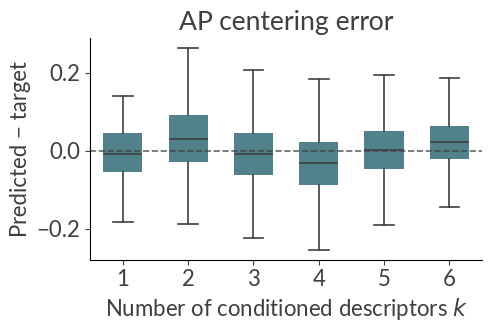

In [9]:
def build_error_df(samples_df: pd.DataFrame, feature: str, pred_col: str):
    """
    Build a dataframe of errors (pred - target) for samples where feature is targeted.
    Assumes samples_df contains:
      - params (dict) with target values
      - used_features listing targeted features
      - predicted column pred_col
    """
    df = samples_df.copy()
    df["used_set"] = df["used_features"].apply(lambda u: set(_as_list(u)))
    df = df[df["used_set"].apply(lambda s: feature in s)].copy()
    df = df[df[pred_col].notna()].copy()

    def get_target(p):
        if isinstance(p, dict) and feature in p:
            return p[feature]
        return np.nan

    df["target"] = df["params"].apply(get_target).astype(float)
    df = df[np.isfinite(df["target"].to_numpy(dtype=float))]
    df["error"] = df[pred_col].astype(float) - df["target"]
    return df[["cond_idx","k","ood_type","error","target",pred_col,"used_features"]]

def plot_error_box_by_k(error_df: pd.DataFrame, title: str, outpath: str):
    df = error_df.copy()
    df = df[df["ood_type"] == "in_dist"].copy() if "ood_type" in df.columns else df
    ks = sorted(df["k"].unique().tolist())
    data = [df.loc[df["k"] == k, "error"].to_numpy(dtype=float) for k in ks]

    fig, ax = plt.subplots(figsize=(5.2, 3.6))
    bp = ax.boxplot(data, positions=np.arange(1, len(ks)+1), widths=0.6,
                    patch_artist=True, showfliers=False)

    for patch in bp["boxes"]:
        patch.set_facecolor(TEAL[3])
        patch.set_alpha(0.85)
        patch.set_linewidth(0)

    for elem in ["whiskers", "caps", "medians"]:
        for line in bp[elem]:
            line.set_color("#3F3F3F")
            line.set_linewidth(1.2)

    ax.axhline(0.0, linestyle="--", linewidth=1.2, color="#3F3F3F", alpha=0.8)
    ax.set_xticks(np.arange(1, len(ks)+1))
    ax.set_xticklabels([str(k) for k in ks])
    ax.set_xlabel("Number of conditioned descriptors $k$")
    ax.set_ylabel("Predicted − target")
    ax.set_title(title)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    fig.savefig(outpath, format="svg", bbox_inches="tight", dpi=300)
    plt.show()

samples_df["k"] = samples_df["used_features"].apply(lambda u: count_k_used(u, include_length=True))
ap_err = build_error_df(samples_df, feature="ap", pred_col="pred_ap")
plot_error_box_by_k(ap_err, "AP centering error", "fig_ap_error_by_k.svg")

In [11]:
def make_ci_table(cond_summary: pd.DataFrame, use_only_in_dist=True) -> pd.DataFrame:
    """
    Returns a tidy table with mean and 95% CI over conditions.
    """
    df = cond_summary.copy()
    if use_only_in_dist and "ood_type" in df.columns:
        df = df[df["ood_type"] == "in_dist"].copy()

    metrics = [
        ("All-target success rate", "all_target_success_rate"),
        ("Within-cond uniqueness (%)", "uniq_pct"),
        ("Within-cond mean NED", "ned_within_mean_from_within_df" if "ned_within_mean_from_within_df" in df.columns else None),
        ("Within-cond mean NW %id", "sim_gen_within_mean"),
        ("Gen-vs-train mean NW %id", "sim_train_mean"),
    ]

    # Add per-descriptor match rates
    for f in FEATURES:
        metrics.append((f"Match rate: {f}", f"match_rate_{f}"))

    rows = []
    for name, col in metrics:
        if col is None or col not in df.columns:
            continue
        mean, lo, hi = bootstrap_ci_over_conditions(df, col)
        rows.append({
            "metric": name,
            "mean": mean,
            "ci_low": lo,
            "ci_high": hi
        })

    out = pd.DataFrame(rows)

    # Prettify (rates as % where appropriate)
    def _fmt(row):
        m = row["mean"]
        lo = row["ci_low"]
        hi = row["ci_high"]
        if "rate" in row["metric"].lower() or "%id" in row["metric"].lower():
            return f"{100*m:.1f} [{100*lo:.1f}, {100*hi:.1f}]"
        if "(%)" in row["metric"]:
            return f"{m:.1f} [{lo:.1f}, {hi:.1f}]"
        return f"{m:.3f} [{lo:.3f}, {hi:.3f}]"

    out["mean [95% CI]"] = out.apply(_fmt, axis=1)
    return out[["metric", "mean [95% CI]"]]

ci_table = make_ci_table(cond_summary, use_only_in_dist=True)
ci_table


,metric,mean [95% CI]
0,All-target success rate,"51.1 [45.0, 57.1]"
1,Within-cond uniqueness (%),"100.0 [100.0, 100.0]"
2,Within-cond mean NED,"0.912 [0.908, 0.917]"
3,Within-cond mean NW %id,"9.3 [8.9, 9.7]"
4,Gen-vs-train mean NW %id,"9.6 [9.5, 9.7]"
5,Match rate: length,"99.8 [99.5, 100.0]"
6,Match rate: is_assembled,"80.9 [77.4, 84.2]"
7,Match rate: ap,"79.7 [76.0, 83.4]"
8,Match rate: has_beta_sheet_content,"97.7 [94.3, 99.8]"
9,Match rate: hydrophobic_moment,"62.6 [58.0, 67.0]"


\begin{tabular}{ll}
\toprule
metric & mean [95% CI] \\
\midrule
All-target success rate & 51.1 [45.0, 57.1] \\
Within-cond uniqueness (%) & 100.0 [100.0, 100.0] \\
Within-cond mean NED & 0.912 [0.908, 0.917] \\
Within-cond mean NW %id & 9.3 [8.9, 9.7] \\
Gen-vs-train mean NW %id & 9.6 [9.5, 9.7] \\
Match rate: length & 99.8 [99.5, 100.0] \\
Match rate: is_assembled & 80.9 [77.4, 84.2] \\
Match rate: ap & 79.7 [76.0, 83.4] \\
Match rate: has_beta_sheet_content & 97.7 [94.3, 99.8] \\
Match rate: hydrophobic_moment & 62.6 [58.0, 67.0] \\
Match rate: net_charge & 70.1 [60.5, 79.4] \\
\bottomrule
\end{tabular}



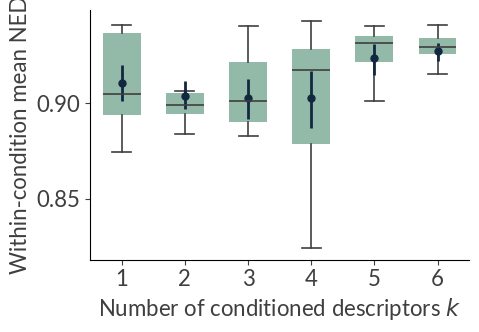

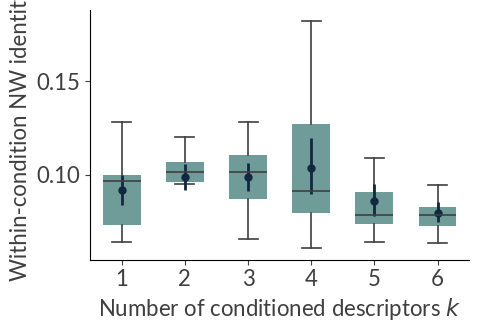

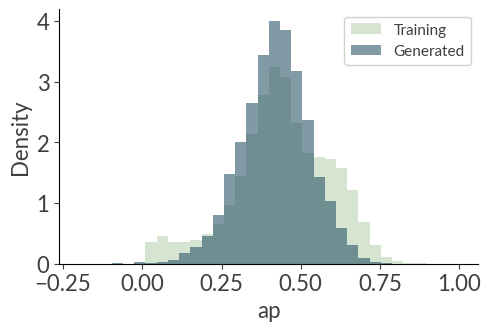

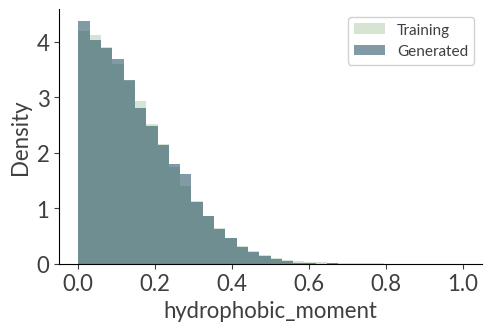

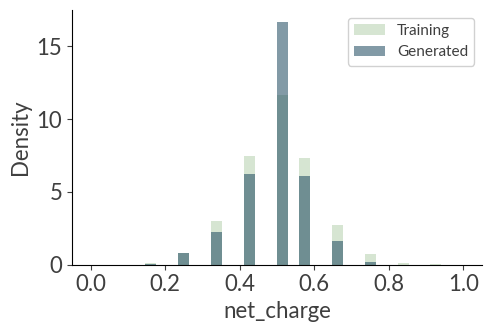

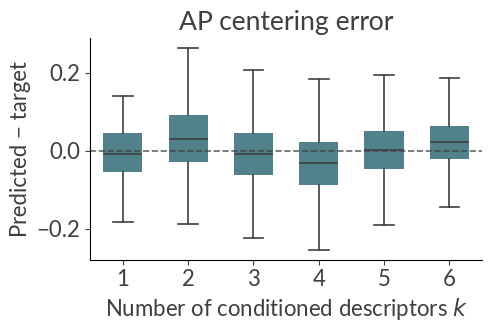

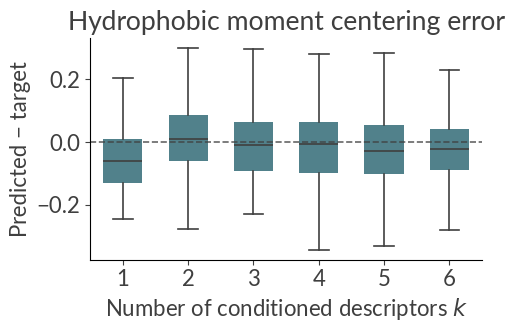

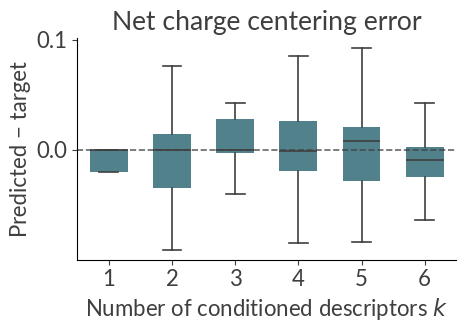

In [13]:
# 1) Load results
samples_df, within_df, _ = load_results_pickle("./results/cvae_evaluation_results.pkl")

# 2) Merge NED-within from within_df
cond_summary = build_condition_summary(samples_df, include_length_in_k=True)
if within_df is not None:
    cond_summary = cond_summary.merge(within_df[["cond_idx","mean"]].rename(columns={"mean":"ned_within_mean_from_within_df"}),
                                      on="cond_idx", how="left")

# 3) Table with CIs
ci_table = make_ci_table(cond_summary, use_only_in_dist=True)
print(ci_table.to_latex(index=False, escape=False))

# 4) Figures
plot_within_condition_ned_by_k(cond_summary, outpath="figS_within_ned_by_k.svg")
plot_within_condition_nw_by_k(cond_summary, outpath="figS_within_nw_by_k.svg")

# 5) Distribution fidelity
train_df = pd.read_csv("../../dataset/merged_all.csv", keep_default_na=False, na_values=[''])
gen_in = samples_df[samples_df["ood_type"] == "in_dist"].copy()

plot_marginal_distribution_overlay(train_df, gen_in, feature="ap", pred_col="pred_ap",
                                   outpath="figS_ap_marginal.svg")
plot_marginal_distribution_overlay(train_df, gen_in, feature="hydrophobic_moment", pred_col="pred_hydrophobic_moment",
                                   outpath="figS_hm_marginal.svg")
plot_marginal_distribution_overlay(train_df, gen_in, feature="net_charge", pred_col="pred_net_charge",
                                   outpath="figS_charge_marginal.svg")

# 6) Conditional centering error plots (one per descriptor)
samples_df["k"] = samples_df["used_features"].apply(lambda u: count_k_used(u, include_length=True))

ap_err = build_error_df(samples_df, feature="ap", pred_col="pred_ap")
plot_error_box_by_k(ap_err, "AP centering error", "figS_ap_error_by_k.svg")

hm_err = build_error_df(samples_df, feature="hydrophobic_moment", pred_col="pred_hydrophobic_moment")
plot_error_box_by_k(hm_err, "Hydrophobic moment centering error", "figS_hm_error_by_k.svg")

ch_err = build_error_df(samples_df, feature="net_charge", pred_col="pred_net_charge")
plot_error_box_by_k(ch_err, "Net charge centering error", "figS_charge_error_by_k.svg")